## Imports & Config

In [1]:
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras

2026-03-01 13:38:45.407249: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772372325.618706      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772372325.677245      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772372326.150769      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772372326.150842      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772372326.150848      55 computation_placer.cc:177] computation placer alr

## Define Constants

In [2]:
data_dir="/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color"

IMG_SIZE=224
BATCH_SIZE=32
SEED=42

## First Create 70% Train Split

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

Found 54305 files belonging to 38 classes.
Using 38014 files for training.


I0000 00:00:1772372381.132155      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 54305 files belonging to 38 classes.
Using 16291 files for validation.


## Split Temp into Validation & Test

In [4]:
temp_batches=tf.data.experimental.cardinality(temp_ds)
val_size=temp_batches//2

val_ds=temp_ds.take(val_size)
test_ds=temp_ds.skip(val_size)

## Confirm Split Sizes

In [5]:
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches: ",tf.data.experimental.cardinality(test_ds).numpy())

Train batches: 1188
Validation batches: 255
Test batches:  255


## Normalization Layer

In [6]:
normalization_layer=tf.keras.layers.Rescaling(1./255)

train_ds=train_ds.map(lambda x,y:(normalization_layer(x),y))
val_ds=val_ds.map(lambda x,y:(normalization_layer(x),y))
test_ds=test_ds.map(lambda x,y:(normalization_layer(x),y))

## Add Data Augmentation (Train Only)

In [7]:
data_augmentation=tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [8]:
train_ds=train_ds.map(
    lambda x,y:(data_augmentation(x,training=True),y)
)

## Optimize Pipeline Performance

In [9]:
AUTOTUNE=tf.data.AUTOTUNE

train_df=train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds=val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds=test_ds.prefetch(buffer_size=AUTOTUNE)

# **Baseline CNN**

In [10]:
from tensorflow.keras import layers, models

num_classes=38

baseline_model=models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(256,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile Model

In [11]:
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Add Callbacks

In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop=EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr=ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

In [15]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 1


## Train Model

In [14]:
history=baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop,reduce_lr]
)

Epoch 1/20


I0000 00:00:1772372421.426684     129 service.cc:152] XLA service 0x7fb3b0007c10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772372421.426724     129 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772372421.871088     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


   1/1188 ━━━━━━━━━━━━━━━━━━━━ 2:28:03 7s/step - accuracy: 0.0312 - loss: 3.6533

I0000 00:00:1772372426.572107     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 453s 375ms/step - accuracy: 0.3651 - loss: 2.4273 - val_accuracy: 0.6996 - val_loss: 1.0308 - learning_rate: 0.0010
Epoch 2/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 427s 359ms/step - accuracy: 0.6544 - loss: 1.1611 - val_accuracy: 0.7515 - val_loss: 0.7825 - learning_rate: 0.0010
Epoch 3/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 425s 357ms/step - accuracy: 0.7316 - loss: 0.8849 - val_accuracy: 0.8034 - val_loss: 0.5966 - learning_rate: 0.0010
Epoch 4/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 424s 356ms/step - accuracy: 0.7773 - loss: 0.7202 - val_accuracy: 0.8651 - val_loss: 0.4033 - learning_rate: 0.0010
Epoch 5/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 425s 357ms/step - accuracy: 0.8055 - loss: 0.6239 - val_accuracy: 0.8789 - val_loss: 0.3660 - learning_rate: 0.0010
Epoch 6/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 422s 355ms/step - accuracy: 0.8219 - loss: 0.5820 - val_accuracy: 0.8974 - val_loss: 0.3092 - learning_rate: 0.0010
Epoch 7/20
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 420s 353ms/step - acc

In [16]:
test_loss, test_accuracy = baseline_model.evaluate(test_ds)
print("Test Accuracy:", test_accuracy)

255/255 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.9451 - loss: 0.1817
Test Accuracy: 0.9478538632392883


In [19]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true=[]
y_pred=[]

for images,labels in test_ds:
    preds=baseline_model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds,axis=1))

y_true=np.array(y_true)
y_pred=np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━

In [20]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.78      0.86        93
           1       0.89      1.00      0.94        98
           2       0.97      0.95      0.96        40
           3       0.95      0.95      0.95       248
           4       0.96      0.99      0.97       213
           5       0.99      0.95      0.97       182
           6       0.96      1.00      0.98       132
           7       0.75      0.87      0.81        86
           8       0.99      1.00      0.99       164
           9       0.91      0.82      0.86       141
          10       1.00      0.98      0.99       163
          11       0.94      0.98      0.96       206
          12       0.98      0.95      0.97       195
          13       0.97      0.98      0.98       167
          14       0.98      0.95      0.97        64
          15       1.00      1.00      1.00       823
          16       0.96      0.97      0.97       339
          17       0.97    

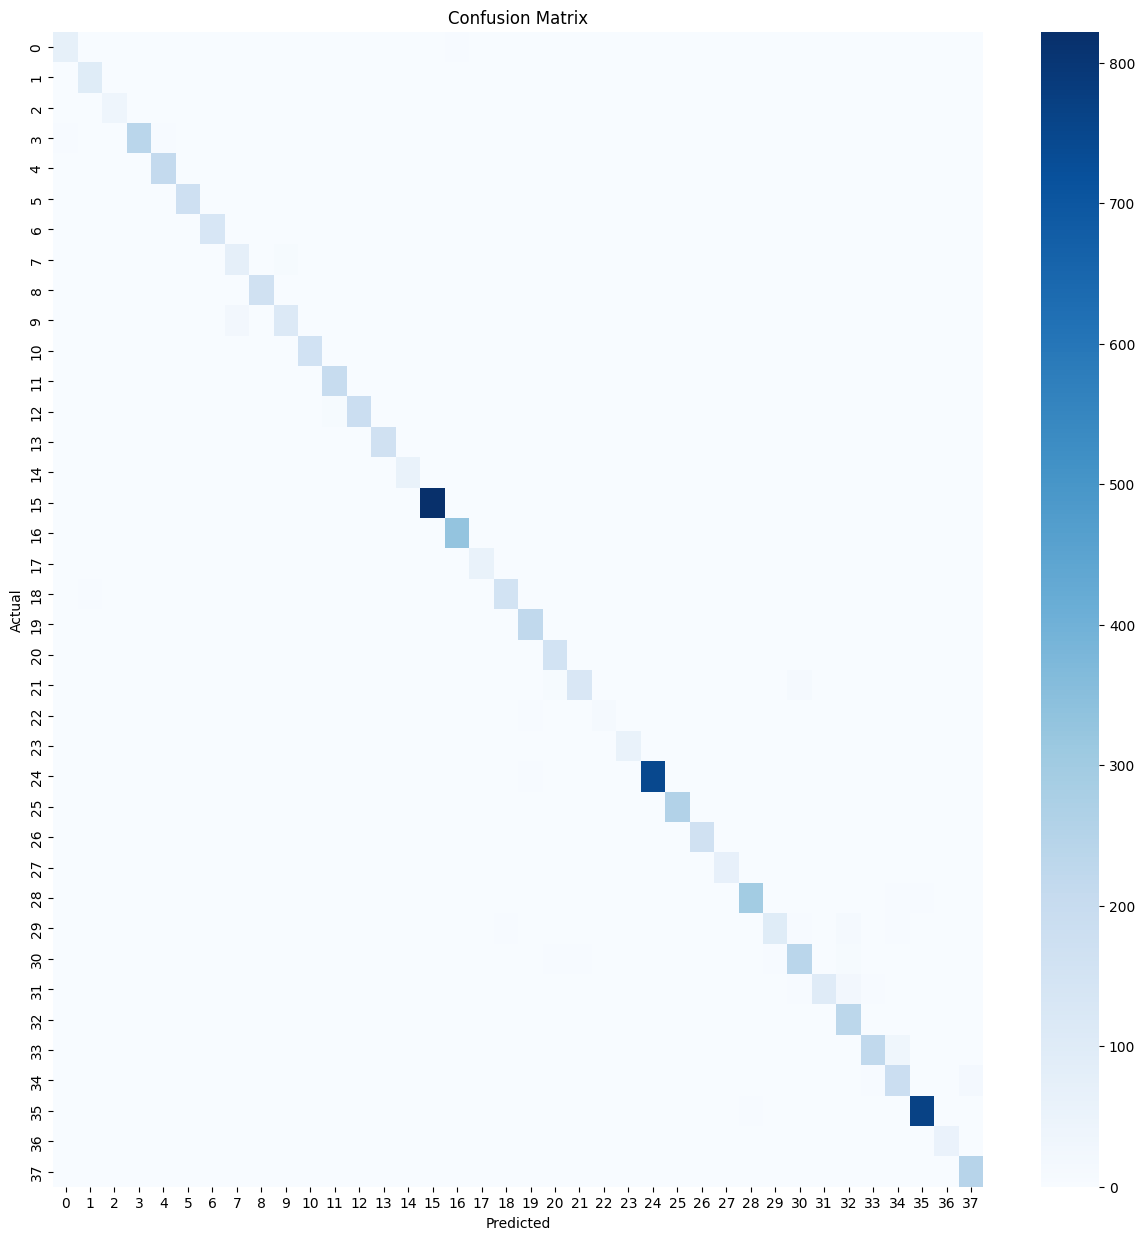

In [21]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(15,15))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()